In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# In this file we load an image, which is a single entry of a whole dataset. We then visualize it

In [2]:
from DNAnet.data.data_models.hid_image import HIDImage
from DNAnet.data.data_models import Panel
from DNAnet.evaluation.visualizations import plot_profile, plot_profile_markers


import matplotlib.pyplot as plt
import numpy as np

## NFI Image

In [3]:
panel = Panel("resources/data/SGPanel_PPF6C_SPOOR.xml")
image = HIDImage(
  path="resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6B2_A03_03.hid",
  annotations_file="resources/data/2p_5p_Dataset_NFI/.txt bestanden 2024 naam/Dataset 1 DTL_AlleleReport.txt",
  panel=panel,
  include_size_standard=True,
  meta={'annotations_name': '1L_07842_6B2'}
)

print(image.data.shape)
# print(image.annotation)
# print(image.meta)

(6, 4096, 1)


### Metadata

In [4]:
# print('image data info:')
# print(image.data.shape)       # shape (5, 4096, 1)
# print(np.max(image.data))     # peak height max

# # print(image.meta)             # Includes run info, dye labels, marker names

# print('image annotation info:')
# print(image.annotation)       # Binary segmentation (same shape as data)

# print(image.meta['annotations_name'])

# print(image.meta.get('called_alleles'))  # List of allele calls (if annotations provided)

### Visualization

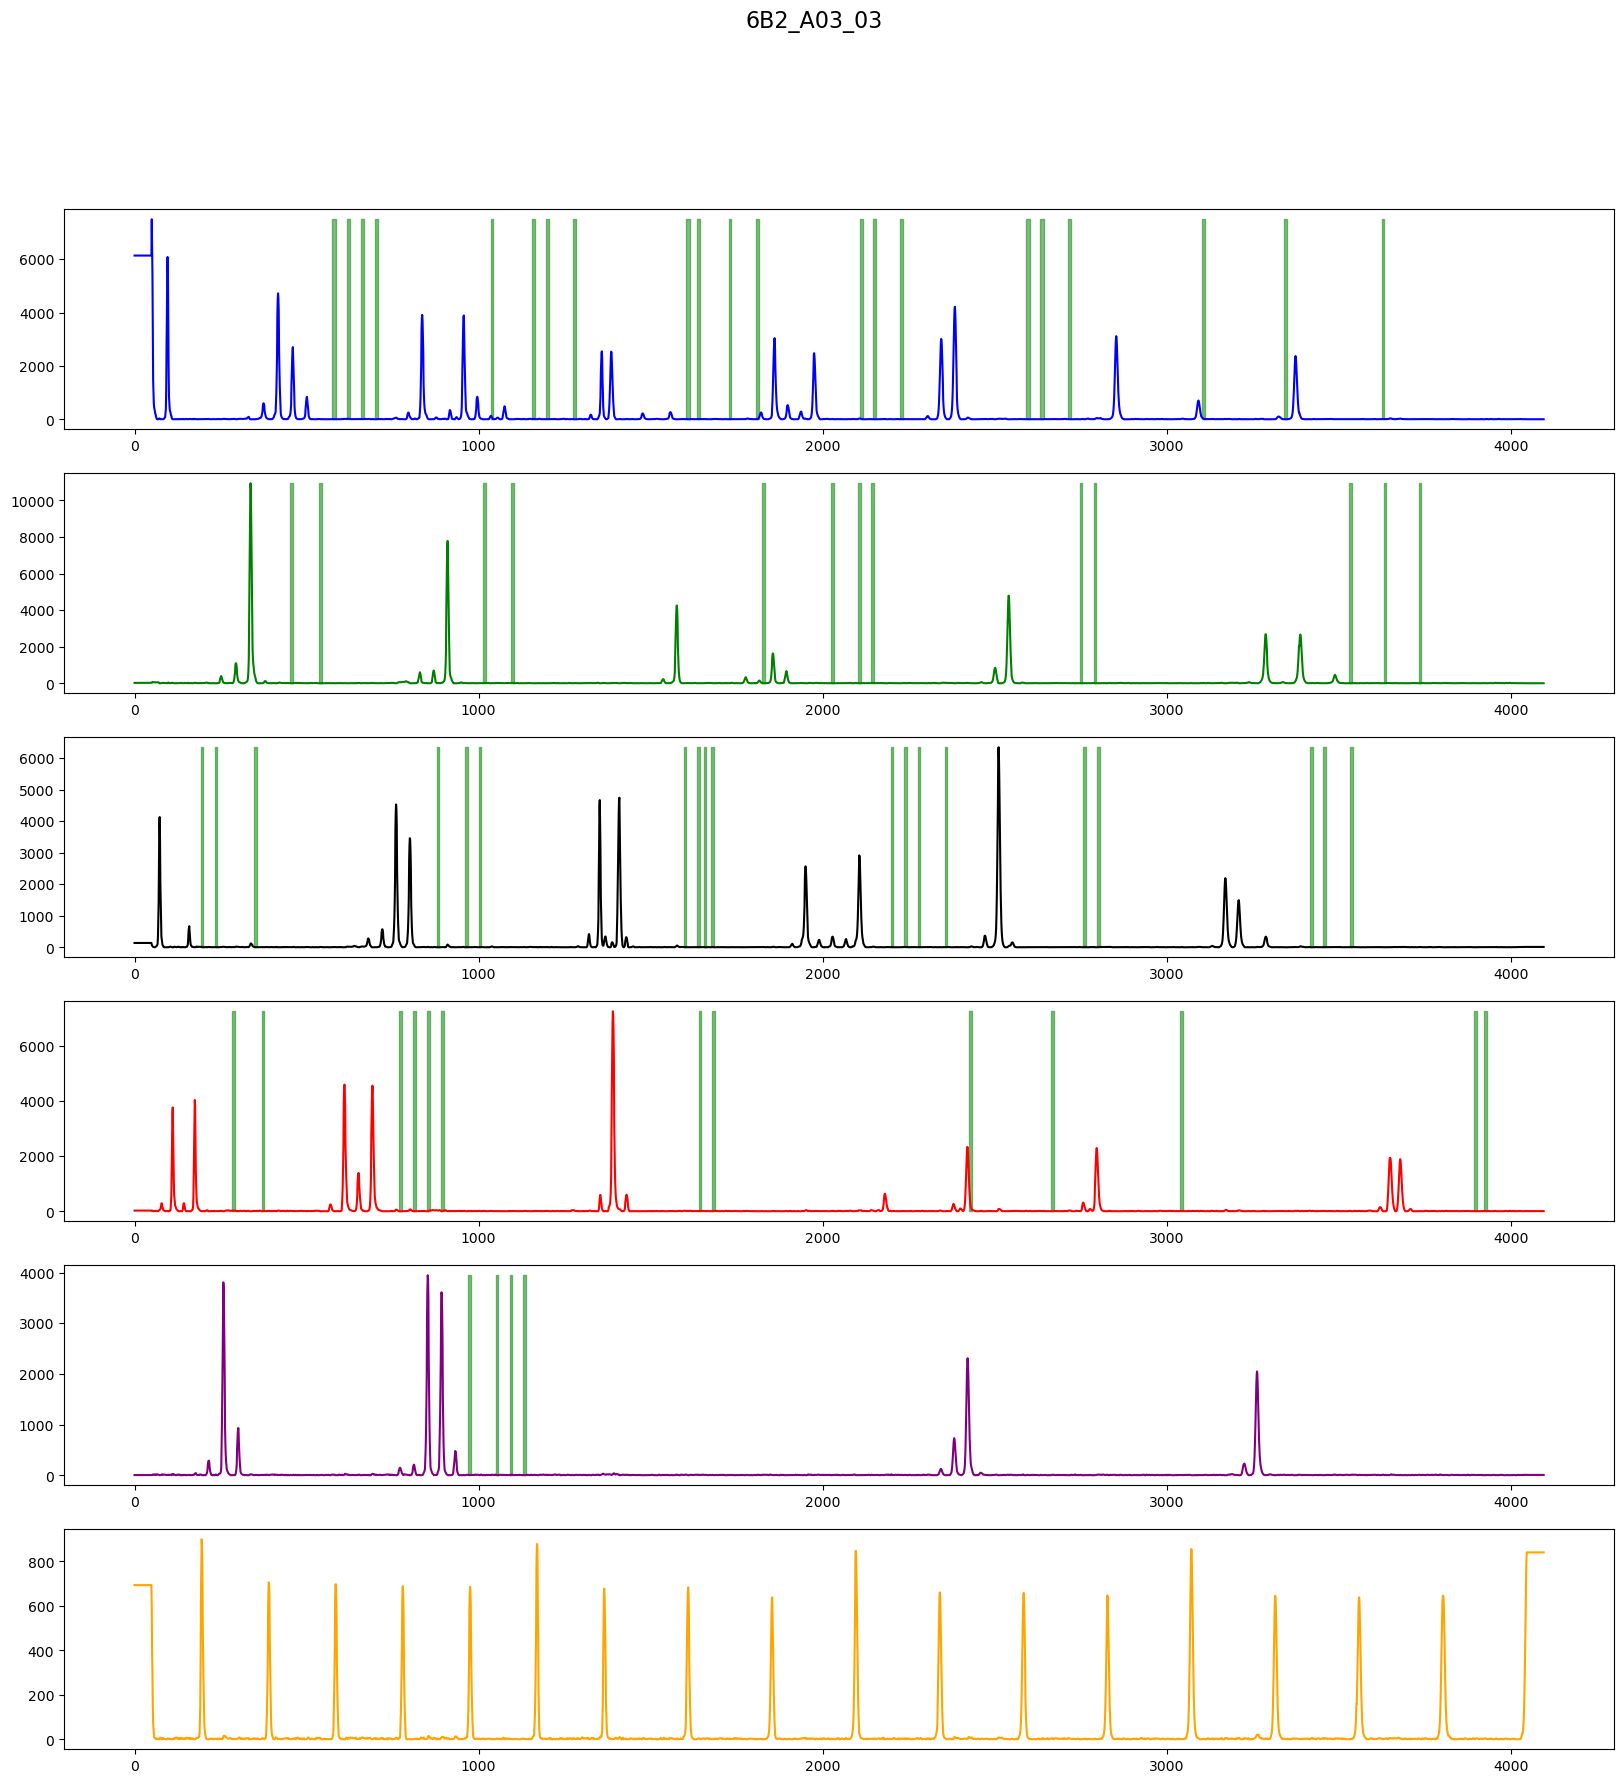

In [5]:
plot_profile(hid_images=[image])

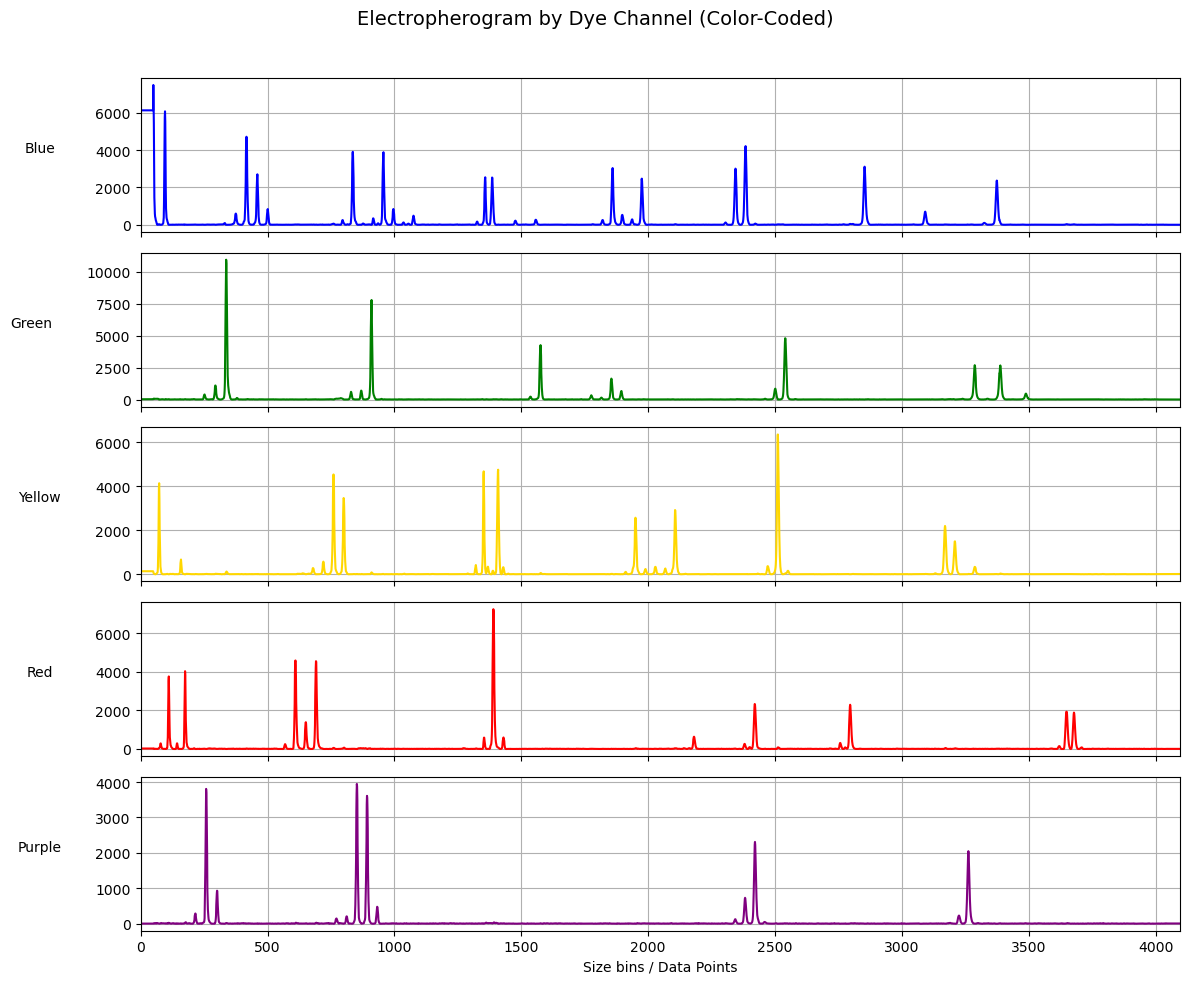

In [6]:
epg = image.data.squeeze()  # shape: (5, 4096)

dye_labels = ['Blue', 'Green', 'Yellow', 'Red', 'Purple']
dye_colors = ['blue', 'green', 'gold', 'red', 'purple']

fig, axs = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

for i in range(5):
    axs[i].plot(epg[i], color=dye_colors[i])
    axs[i].set_ylabel(dye_labels[i], rotation=0, labelpad=40, fontsize=10)
    axs[i].grid(True)
    axs[i].set_xlim(0, epg.shape[1])

axs[-1].set_xlabel("Size bins / Data Points")
plt.suptitle("Electropherogram by Dye Channel (Color-Coded)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


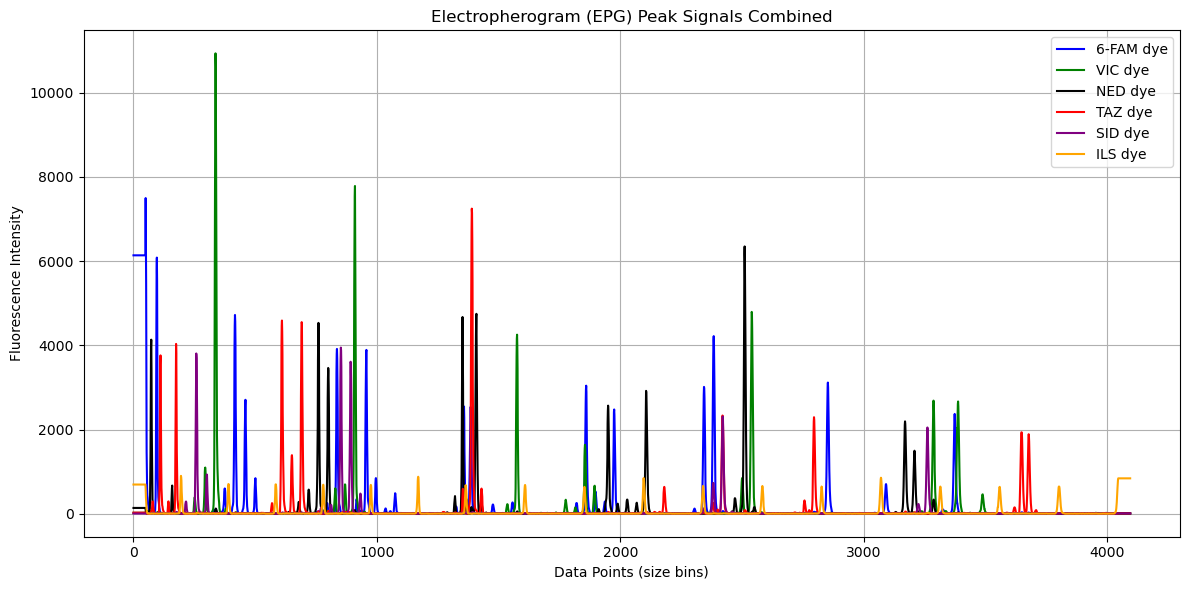

In [7]:
from DNAnet.data.parsing.parse_raw_hid import get_peak_data
from DNAnet.evaluation.visualizations import DNA_CHANNELS, GF_DYE_NAMES


# epg = get_peak_data(image.path)[4000:] # shape: (6, 4096)

def plot_epg_together(epg):
    plt.figure(figsize=(12, 6))

    for i in range(epg.shape[0]):
        plt.plot(epg[i], label=f'{GF_DYE_NAMES[i]} dye', color=DNA_CHANNELS[i])

    plt.xlabel("Data Points (size bins)")
    plt.ylabel("Fluorescence Intensity")
    plt.title("Electropherogram (EPG) Peak Signals Combined")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("figures/EPG-one-lane.pdf")
    plt.show()

plot_epg_together(epg)